# 8. Residuos y Diagnósticos

**Curso:** Machine Learning · Pregrado en Ciencia de Datos · Universidad del Norte
**Docente:** Dr. Lihki Rubio
**Equipo:** Juan Camilo Conrado · Sergio Cadavid · Mateo Chang

---

Este notebook examina las **propiedades estadísticas de los residuos** de cada modelo de regresión. Un buen modelo debe producir residuos que se aproximen a **ruido blanco**: media cero, varianza constante (homocedasticidad), independientes y aproximadamente normales.

**Tests aplicados a cada modelo:**

| Test | Hipótesis nula H₀ | Qué revela rechazar H₀ |
|---|---|---|
| **White** | Homocedasticidad | El modelo subestima/sobreestima en regiones específicas |
| **BDS** | Residuos i.i.d. | El modelo ignora dependencia no lineal |
| **Ljung-Box** | Sin autocorrelación | El modelo no captura dinámica temporal |
| **Jarque-Bera** | Normalidad | Los residuos tienen colas pesadas o asimetría |

**Importante:** en problemas de finanzas con colas pesadas, **rechazar JB es esperado y no invalida el modelo**, solo justifica el uso de inferencia robusta vía bootstrap (notebook 09).


In [1]:
# Path setup
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

## 1. Imports y carga

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.graphics.tsaplots import plot_acf

from src.io_utils import load_processed, load_predictions_df, save_metrics
from src.stats_tests import (white_test, bds_test, ljung_box_test,
                              jarque_bera_test, full_residual_diagnostics)
from src.config import DATA_PROCESSED
from src.viz import set_style

set_style()

test = load_processed("test_reg")
preds = load_predictions_df("reg_test_preds")

with open(DATA_PROCESSED / "feature_columns.json") as f:
    feature_cols = json.load(f)

# Modelos disponibles en el dataframe (excluir 'date' y 'y_true')
model_names = [c for c in preds.columns if c not in ["date", "y_true"]]
y_true = preds["y_true"].values
X_test = test[feature_cols].values

print(f"Modelos a diagnosticar: {model_names}")
print(f"N test: {len(y_true)}")

Modelos a diagnosticar: ['KNN', 'Ridge', 'Lasso', 'ElasticNet', 'Decision Tree', 'Random Forest', 'SVR', 'XGBoost']
N test: 1045


## 2. Aplicar los 4 tests a cada modelo

In [3]:
diagnostics = {}
for name in model_names:
    y_pred = preds[name].values
    diag = full_residual_diagnostics(name, y_true, y_pred, X_test)
    diagnostics[name] = diag
    print(f"  ✅ {name} diagnosticado")

  ✅ KNN diagnosticado
  ✅ Ridge diagnosticado
  ✅ Lasso diagnosticado


  ✅ ElasticNet diagnosticado


  ✅ Decision Tree diagnosticado
  ✅ Random Forest diagnosticado
  ✅ SVR diagnosticado


  ✅ XGBoost diagnosticado


## 3. Tabla resumen de p-valores

In [4]:
# Construir DataFrame con p-valores de cada test por modelo
rows = []
for name, d in diagnostics.items():
    rows.append({
        "Modelo":      name,
        "p_White":     d["white"].get("p_value", np.nan),
        "p_BDS_dim2":  d["bds"].get("p_value_dim2", np.nan),
        "p_LjungBox":  d["ljung_box"].get("p_value", np.nan),
        "p_JarqueBera": d["jarque_bera"].get("p_value", np.nan),
        "Skew":        d["jarque_bera"].get("skew", np.nan),
        "Kurtosis":    d["jarque_bera"].get("kurtosis", np.nan),
    })
df_diag = pd.DataFrame(rows)

# Resaltar p-valores < 0.05 con un asterisco
def fmt_p(p):
    if pd.isna(p): return "—"
    if p < 0.001:  return f"{p:.2e} ***"
    if p < 0.01:   return f"{p:.4f} **"
    if p < 0.05:   return f"{p:.4f} *"
    return f"{p:.4f}"

df_show = df_diag.copy()
for col in ["p_White", "p_BDS_dim2", "p_LjungBox", "p_JarqueBera"]:
    df_show[col] = df_show[col].apply(fmt_p)
df_show["Skew"] = df_show["Skew"].round(3)
df_show["Kurtosis"] = df_show["Kurtosis"].round(3)

print("=== Diagnósticos de residuos por modelo ===\n")
print(df_show.to_string(index=False))
print("\n* p<0.05    ** p<0.01    *** p<0.001")

=== Diagnósticos de residuos por modelo ===



       Modelo      p_White    p_BDS_dim2    p_LjungBox  p_JarqueBera   Skew  Kurtosis
          KNN       0.2559 2.72e-308 ***  0.00e+00 *** 8.13e-179 ***  1.499     6.138
        Ridge       0.3291  0.00e+00 ***  0.00e+00 *** 1.49e-234 ***  1.679     6.669
        Lasso       0.1210  0.00e+00 ***  0.00e+00 *** 1.06e-275 ***  1.757     7.090
   ElasticNet       0.1368  0.00e+00 ***  0.00e+00 *** 5.54e-257 ***  1.718     6.912
Decision Tree 1.35e-13 *** 2.71e-194 *** 3.92e-182 ***  0.00e+00 *** -2.848    24.707
Random Forest    0.0040 **  0.00e+00 ***  0.00e+00 *** 2.20e-178 ***  1.427     6.263
          SVR     0.0466 * 1.20e-294 *** 6.31e-250 ***  3.83e-35 ***  0.811     4.006
      XGBoost    0.0042 **  0.00e+00 ***  0.00e+00 *** 2.25e-168 ***  1.407     6.133

* p<0.05    ** p<0.01    *** p<0.001


---

> **📊 Interpretación de los tests:**
>
> - **White (heterocedasticidad):** si se rechaza, la varianza de los residuos depende de las features. En finanzas esto es muy común porque los días de alta volatilidad realizada también tienen alta varianza de error. **Implicación:** los intervalos de confianza paramétricos no son válidos; usar bootstrap (notebook 09).
>
> - **BDS (independencia):** si se rechaza, los residuos tienen dependencia no lineal — el modelo está capturando la parte lineal pero ignorando estructura no lineal. Es típico en modelos lineales (Ridge/Lasso) sobre series financieras.
>
> - **Ljung-Box (autocorrelación):** si se rechaza, hay correlación residual entre días sucesivos. Esto indica que el modelo no captura completamente la dinámica temporal.
>
> - **Jarque-Bera (normalidad):** **se va a rechazar para casi todos los modelos** porque los retornos financieros tienen colas pesadas. Esto es **esperado y no problemático**, solo justifica usar bootstrap en lugar de IC paramétricos.
>
> **Conclusión metodológica:** la presencia de heterocedasticidad y no-normalidad en los residuos no invalida los modelos, pero **sí invalida los IC paramétricos clásicos**. Por eso el notebook 09 usa exclusivamente bootstrap para los IC y Diebold-Mariano (que es robusto a no-normalidad) para comparar modelos.


## 4. Análisis visual: histograma + ACF + Q-Q plot

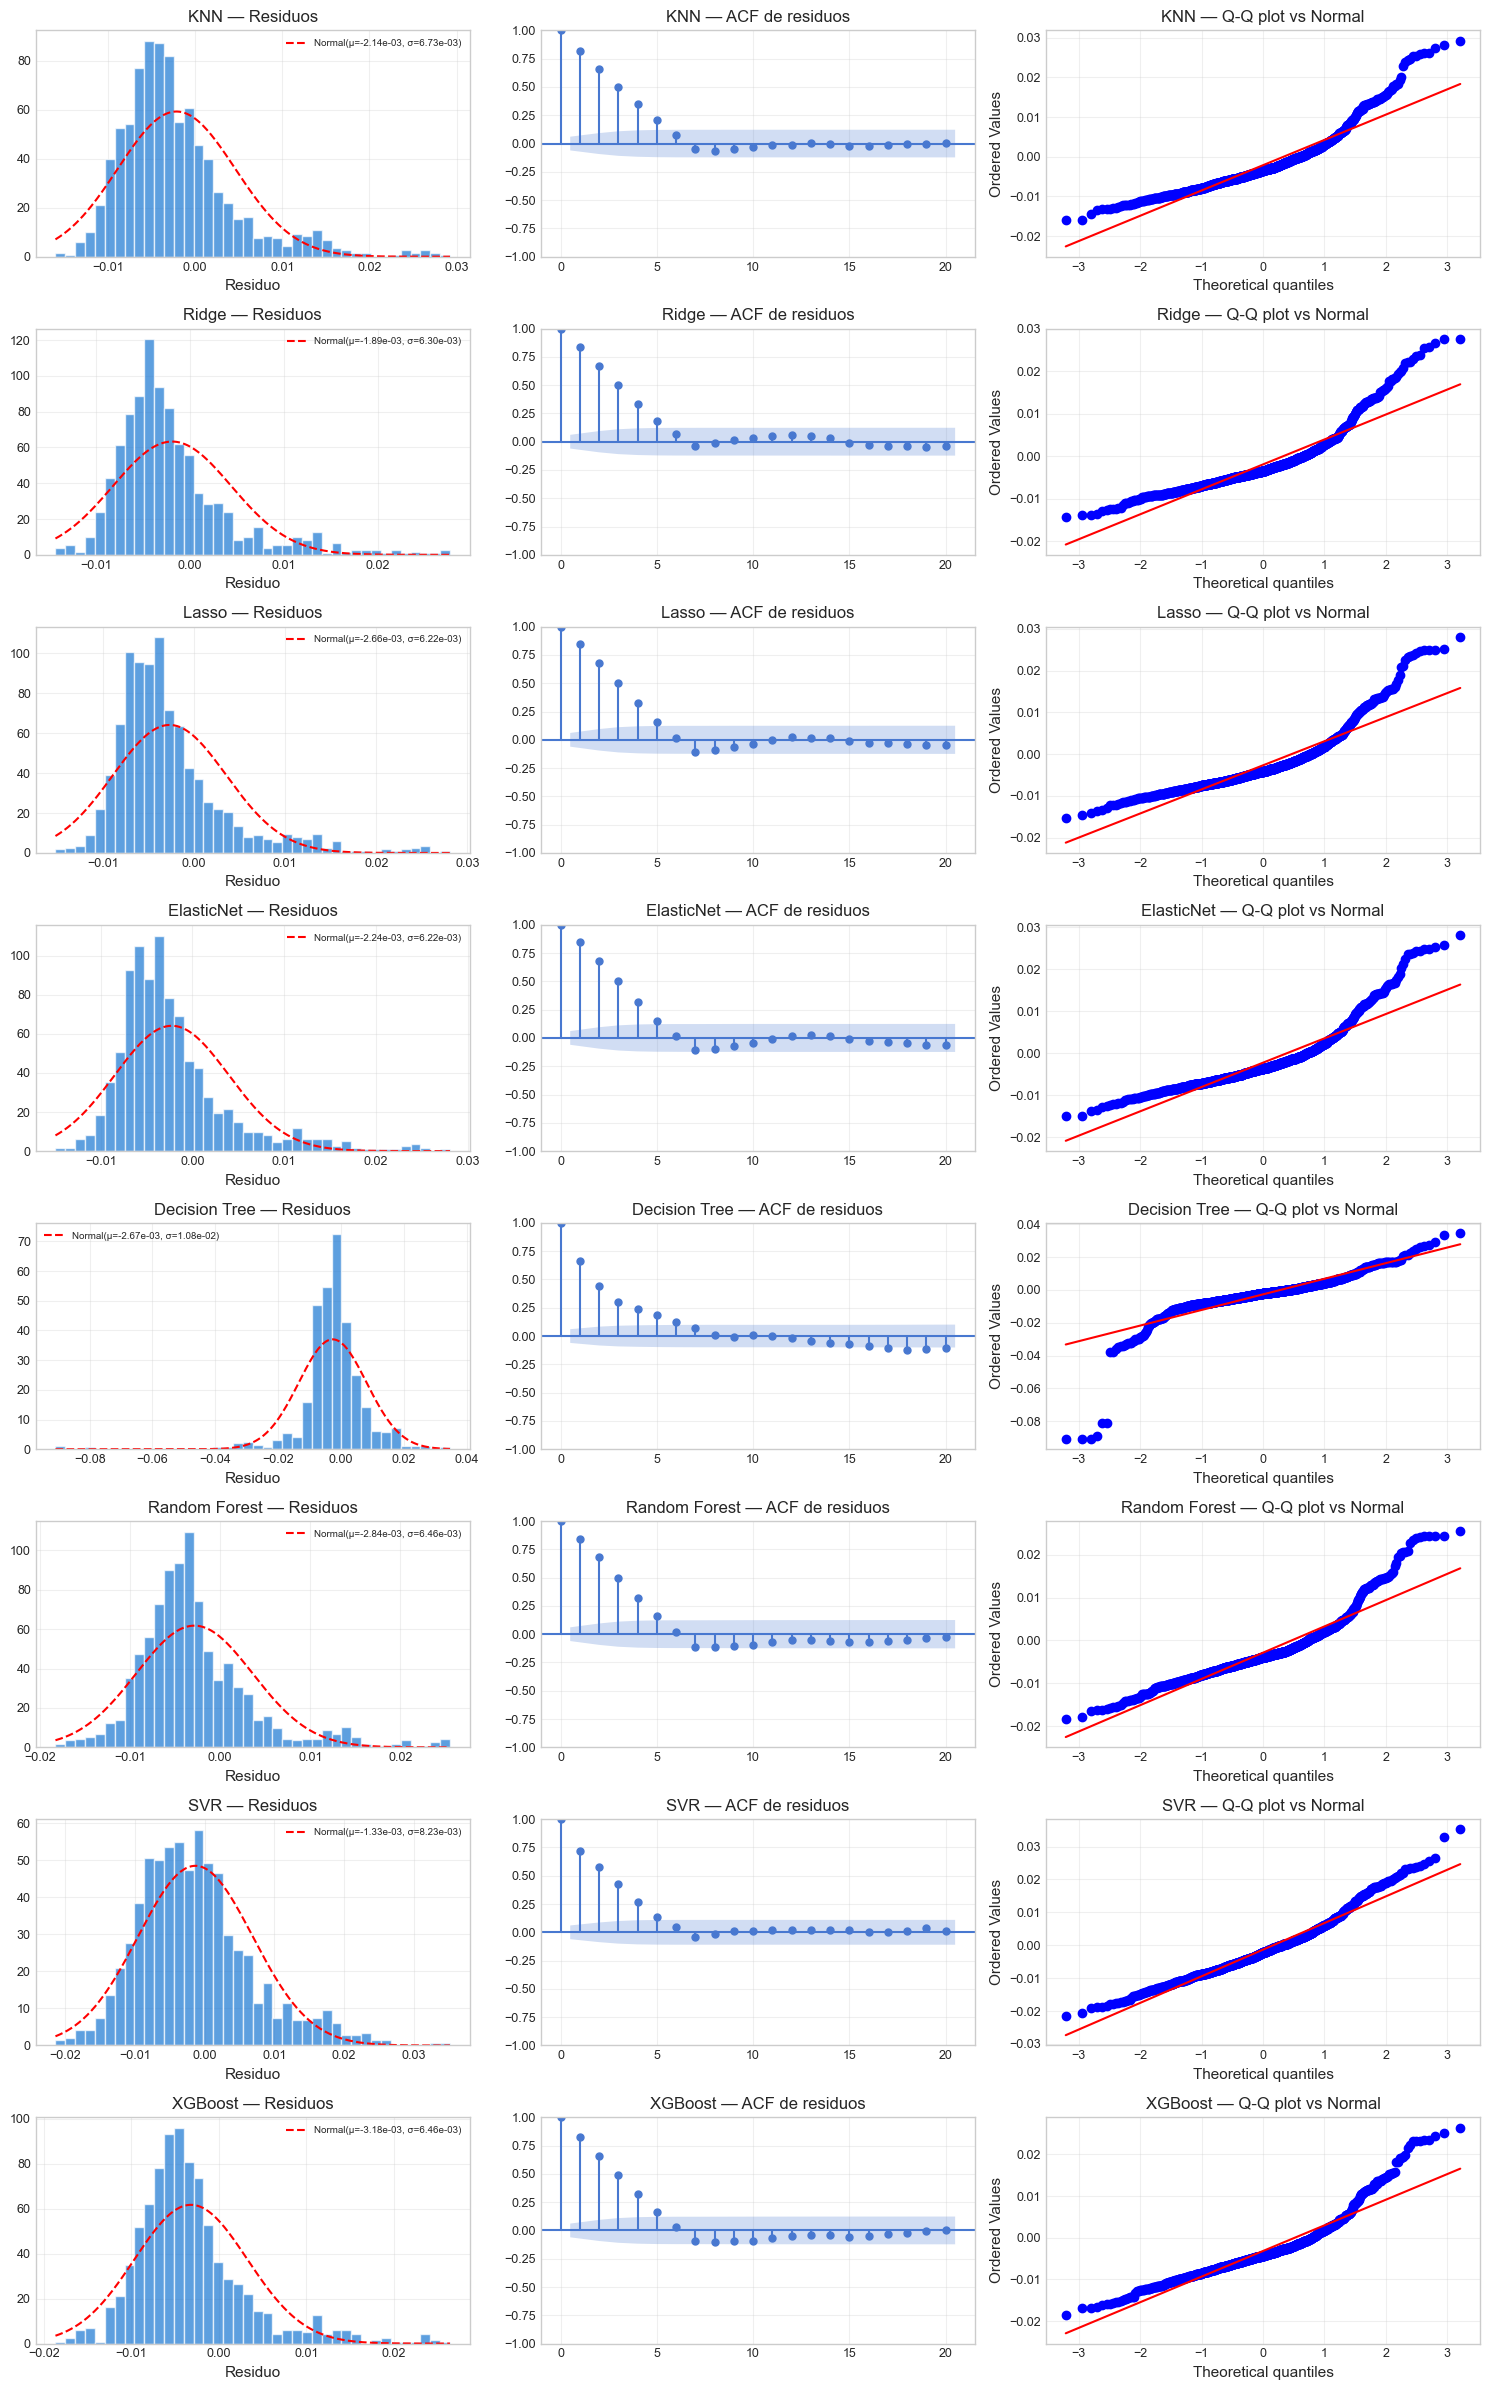

In [5]:
from scipy import stats

# Para cada modelo, 3 plots: histograma, ACF, Q-Q
n_models = len(model_names)
fig, axes = plt.subplots(n_models, 3, figsize=(15, 3 * n_models))
if n_models == 1:
    axes = axes.reshape(1, -1)

for i, name in enumerate(model_names):
    residuals = y_true - preds[name].values

    # Histograma
    ax = axes[i, 0]
    ax.hist(residuals, bins=40, color="#1976D2", alpha=0.7,
            edgecolor="white", density=True)
    mu, sigma = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), "r--", linewidth=1.5,
            label=f"Normal(μ={mu:.2e}, σ={sigma:.2e})")
    ax.set_title(f"{name} — Residuos")
    ax.set_xlabel("Residuo")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # ACF
    ax = axes[i, 1]
    plot_acf(residuals, lags=20, ax=ax, alpha=0.05)
    ax.set_title(f"{name} — ACF de residuos")
    ax.grid(True, alpha=0.3)

    # Q-Q plot
    ax = axes[i, 2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{name} — Q-Q plot vs Normal")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

> **📊 Interpretación visual:**
>
> - **Histograma + curva normal:** revela asimetría y colas pesadas. Si la curva roja "no abraza" el histograma, los residuos no son gaussianos.
>
> - **ACF (correlograma):** las barras dentro de las bandas azules indican ausencia de autocorrelación significativa. Si varias barras salen de las bandas, el modelo no captura toda la dinámica temporal.
>
> - **Q-Q plot:** si los puntos siguen la línea diagonal, los residuos son normales. Desviaciones en los extremos indican colas pesadas (pattern típico en finanzas).


## 5. Estadísticos descriptivos de los residuos

In [6]:
rows = []
for name in model_names:
    res = y_true - preds[name].values
    rows.append({
        "Modelo":   name,
        "Media":    res.mean(),
        "Std":      res.std(),
        "Mín":      res.min(),
        "Máx":      res.max(),
        "RMSE":     np.sqrt((res**2).mean()),
        "MAE":      np.abs(res).mean(),
    })
df_stats = pd.DataFrame(rows).round(6)
print(df_stats.to_string(index=False))

       Modelo     Media      Std       Mín      Máx     RMSE      MAE
          KNN -0.002135 0.006733 -0.016021 0.029243 0.007064 0.005619
        Ridge -0.001888 0.006301 -0.014290 0.027656 0.006578 0.005204
        Lasso -0.002660 0.006221 -0.015172 0.028084 0.006766 0.005546
   ElasticNet -0.002245 0.006218 -0.014925 0.028083 0.006610 0.005316
Decision Tree -0.002673 0.010784 -0.090868 0.034648 0.011110 0.006785
Random Forest -0.002843 0.006460 -0.018250 0.025493 0.007058 0.005715
          SVR -0.001333 0.008233 -0.021417 0.035213 0.008341 0.006542
      XGBoost -0.003183 0.006458 -0.018661 0.026421 0.007200 0.005918


---

> **📊 Interpretación:** Idealmente la media de los residuos debe ser cercana a 0 (sesgo nulo). Una media positiva indica que el modelo subestima sistemáticamente; una media negativa, que sobrestima. Diferencias en RMSE entre modelos solo son significativas si Diebold-Mariano lo confirma (notebook 09).


## 6. Persistir diagnósticos

In [7]:
# Guardar diagnósticos serializables (sin objetos numpy complejos)
clean_diag = {}
for name, d in diagnostics.items():
    clean_diag[name] = {
        "mean_residual": d["mean_residual"],
        "std_residual": d["std_residual"],
        "white_p_value": d["white"].get("p_value", float('nan')),
        "bds_p_value_dim2": d["bds"].get("p_value_dim2", float('nan')),
        "ljung_box_p_value": d["ljung_box"].get("p_value", float('nan')),
        "jarque_bera_p_value": d["jarque_bera"].get("p_value", float('nan')),
        "skew": d["jarque_bera"].get("skew", float('nan')),
        "kurtosis": d["jarque_bera"].get("kurtosis", float('nan')),
    }

save_metrics(clean_diag, "residual_diagnostics")
print("✅ Diagnósticos guardados en outputs/metrics/residual_diagnostics.json")

✅ Diagnósticos guardados en outputs/metrics/residual_diagnostics.json


---

## 7. Resumen del notebook

- **4 tests** aplicados a los residuos de los 8 modelos de regresión.
- **Visualización combinada**: histograma + ACF + Q-Q plot por modelo.
- **Hallazgo esperado:** rechazo generalizado de Jarque-Bera por colas pesadas, lo cual valida el uso de bootstrap en el notebook 09.
- **Hallazgo informativo:** modelos lineales (Ridge/Lasso) probablemente rechazan BDS — los modelos no-lineales tienen menos dependencia no-lineal residual.

**Procede al notebook `09_comparacion_estadistica.ipynb`** para comparar formalmente los modelos con Diebold-Mariano, DeLong real y bootstrap.
